# **Necessary Imports**

In [ ]:
!pip install keras_tuner
!pip install scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.6 MB/s eta 0:00:00


In [ ]:
# Numerical arrays
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Neural network
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split

# Data Preprocessing
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Model evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, auc, accuracy_score, precision_recall_curve
import sklearn


# Model optimization
from tensorflow.keras import regularizers
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
from keras_tuner import RandomSearch
from sklearn.model_selection import GridSearchCV

import shap
sklearn.set_config(display='diagram')
from google.colab import drive
drive.mount('/content/drive')

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. **Data Loading and Preprocessing**

In [ ]:
# Reading the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer-telco-churn/data/cleaned/cleaned_data.csv')

In [ ]:
# remove gender and unnamed column since they are not needed
df = df.drop(["gender", "Unnamed: 0"], axis=1)

In [ ]:
# # Check for multicolinareality
# numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# # corr matrix
# corr_matrix = df[numerical_cols].corr()

# # remove multi col

In [ ]:
# # find highly correlatd pairs
# highly_correlated_pairs = []

# for i in range(len(corr_matrix.columns)):
#   for j in range(i):
#     if abs(corr_matrix.iloc[i, j]) > 0.8:
#       highly_correlated_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))


In [ ]:
# # Remove one from each correlated pair
# to_remove = []

# for f1, f2, corr_value in highly_correlated_pairs:
#   # Check correlation with target
#   corr_f1 = df[f1].corr(df['Churn'])
#   corr_f2 = df[f2].corr(df['Churn'])

#   if abs(corr_f1) > abs(corr_f2):   # absolute since the magnitude matters
#     to_remove.append(f2)
#   else:
#     to_remove.append(f1)

In [ ]:
# # Remove duplicates
# to_remove = list(set(to_remove))

In [ ]:
# if to_remove:
#   df = df.drop(to_remove, axis=1)
#   print("Removed features:", to_remove)

# **2. Data Splitting**

In [ ]:
# Seperate independent and dependent variables
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # equal proportions of each class

In [ ]:
# Get categorical (nominal + ordinal), numerical features for later preprocessing
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns.drop('Contract')  # Exclude the ordinal column
ordinal_feature = ['Contract']  # Contracts get better from Month-to-month to One year to Two year

# **3. Create Preprocessing Pipeline**

In [ ]:
# numerical
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())    # standard scaler for neural network
])

# Categorical (excluding ordinal)
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # encode nominal features
])

# Ordinal feature
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[
        ['Month-to-month', 'One year', 'Two year']
    ]))
])

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_feature),
        ('num', numerical_transformer, numerical_features)
    ]
)

In [ ]:
# Fit the preprocessor
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# **4. Handle Class Imbalance with SMOTE**

In [ ]:
# # Fitting smote
# smote = SMOTE(random_state=42)

# X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
# # Getting the new shapes
# print("Training sets sizes after sampling:", X_train_balanced.shape, y_train_balanced.shape)

In [ ]:
# Comoute mi scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

In [ ]:
# Get them as a dataframe
feature_names = preprocessor.get_feature_names_out()

mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

In [ ]:
mi_df.head(20)

,Feature,MI Score
36,ord__Contract,0.097501
38,num__tenure,0.066324
21,cat__TechSupport_No,0.061834
12,cat__OnlineSecurity_No,0.057240
34,cat__PaymentMethod_Electronic check,0.053044
39,num__MonthlyCharges,0.047010
15,cat__OnlineBackup_No,0.045106
10,cat__InternetService_Fiber optic,0.044302
40,num__TotalCharges,0.039633
13,cat__OnlineSecurity_No internet service,0.037612


In [ ]:
selector = SelectKBest(score_func=mutual_info_classif, k=20)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [ ]:
###### check for duplicates

In [ ]:
def create_nn(input_dim,
              hidden_layers=[128,64,32],
              dropout_rate=0.3,
              learning_rate=0.001,
              use_batch_norm=False,
              l2_reg=0.001):

  model = tf.keras.models.Sequential()

  # Input layer
  model.add(tf.keras.layers.Input(shape=(input_dim, )))

  # Add hidden layers
  for i, neurons in enumerate(hidden_layers):
    model.add(tf.keras.layers.Dense(
        neurons,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg),
        name=f'hidden_layer_{i+1}'
    ))

    # If we are using batch norm
    if use_batch_norm:
      model.add(tf.keras.layers.BatchNormalization(name=f'batch_norm_{i+1}'))

    # dropout for regularization
    model.add(tf.keras.layers.Dropout(dropout_rate, name=f'dropout_{i+1}'))


  # Output layer
  model.add(tf.keras.layers.Dense(1, activation='sigmoid', name='output_layer'))

  # Compile model
  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  model.compile(
      optimizer=optimizer,
      loss='binary_crossentropy',
      metrics=['accuracy',
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR')  # precision-recall prc
      ]
  )

  return model

    # Add dropout

In [ ]:
# Get the dimension required for creating the model
input_dim = X_train_selected.shape[1]

# Create the model
neural_network = create_nn(
    input_dim=input_dim,
    hidden_layers=[128,64,32],
    dropout_rate=0.3,
    learning_rate=0.001,
    use_batch_norm=False,
    l2_reg=0.001
)

In [ ]:
# Summary of the created model
neural_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def get_callbacks(patience=15):
  """
  To get the callbacks for early stopping
  """
  early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=patience,    # if it does not improve, then stop after patience epochs
    restore_best_weights=True,  # retunr to the best model without ending at the last
    verbose=1,
    mode='max'    # treats higher values as improvements
  )

  return early_stopping


In [ ]:
# Receive the callbacks
callbacks = get_callbacks()

In [ ]:
# Handle class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',   # treat the minority class as more important
    classes=np.unique(y_train),   # exact order class labels
    y=y_train   # frequencies calculated here
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}  # returned a numpy array

In [ ]:
# Train the network
batch_size = 32
epochs = 100
validation_split = 0.2

trained_model = neural_network.fit(
    X_train_selected,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=callbacks,
    class_weight=class_weight_dict, # handle imbalanced data
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6398 - auc: 0.7353 - loss: 0.7535 - prc: 0.5017 - precision: 0.4115 - recall: 0.7404 - val_accuracy: 0.6815 - val_auc: 0.8200 - val_loss: 0.6876 - val_prc: 0.6116 - val_precision: 0.4418 - val_recall: 0.8237
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7176 - auc: 0.8248 - loss: 0.6351 - prc: 0.5972 - precision: 0.4841 - recall: 0.8270 - val_accuracy: 0.7098 - val_auc: 0.8214 - val_loss: 0.6095 - val_prc: 0.6147 - val_precision: 0.4675 - val_recall: 0.7797
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7316 - auc: 0.8263 - loss: 0.6078 - prc: 0.6139 - precision: 0.4958 - recall: 0.7819 - val_accuracy: 0.7134 - val_auc: 0.8211 - val_loss: 0.6123 - val_prc: 0.6138 - val_precision: 0.4710 - val_recall: 0.7695
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7478 - auc: 0.8399 - loss: 0.5803 - prc: 0.6221 - precision: 0.5186 - recall: 0.8114 - val_accuracy: 0.7107 

In [ ]:
# visualize training history
def visualize_history(model):
  """
  Used to visualize the training history of the model
  """
  fig, axes = plt.subplots(2, 3, figsize=(18,10))

  # plot loss
  axes[0, 0].plot(model.history['loss'], label='Training loss')
  axes[0, 0].plot(model.history['val_loss'], label='Validation loss')
  axes[0, 0].set_title('Model Loss')
  axes[0, 0].set_xlabel('Epoch')
  axes[0, 0].set_ylabel('Loss')
  axes[0, 0].legend()
  axes[0, 0].grid(True, alpha=0.3)

  axes[0, 1].plot(model.history['accuracy'], label='Training accuracy')
  axes[0, 1].plot(model.history['val_accuracy'], label='Validation accuracy')
  axes[0, 1].set_title('Model Accuracy')
  axes[0, 1].set_xlabel('Epoch')
  axes[0, 1].set_ylabel('Accuracy')
  axes[0, 1].legend()
  axes[0, 1].grid(True, alpha=0.3)

  # AUC
  axes[0, 2].plot(model.history['auc'], label='Training AUC')
  axes[0, 2].plot(model.history['val_auc'], label='Validation AUC')
  axes[0, 2].set_title('ROC-AUC')
  axes[0, 2].set_xlabel('Epoch')
  axes[0, 2].set_ylabel('AUC')
  axes[0, 2].legend()
  axes[0, 2].grid(True, alpha=0.3)

  axes[1, 0].plot(model.history['precision'], label='Training precision')
  axes[1, 0].plot(model.history['val_precision'], label='Validation precision')
  axes[1, 0].set_title('Model Precision')
  axes[1, 0].set_xlabel('Epoch')
  axes[1, 0].set_ylabel('Precision')
  axes[1, 0].legend()
  axes[1, 0].grid(True, alpha=0.3)

  axes[1, 1].plot(model.history['recall'], label='Training recall')
  axes[1, 1].plot(model.history['val_recall'], label='Validation recall')
  axes[1, 1].set_title('Model Recall')
  axes[1, 1].set_xlabel('Epoch')
  axes[1, 1].set_ylabel('Recall')
  axes[1, 1].legend()
  axes[1, 1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.savefig('neural_network_history_plots.png', dpi=300, bbox_inches='tight')
  fig.delaxes(axes[1, 2]) # delete the empty plot
  plt.show()


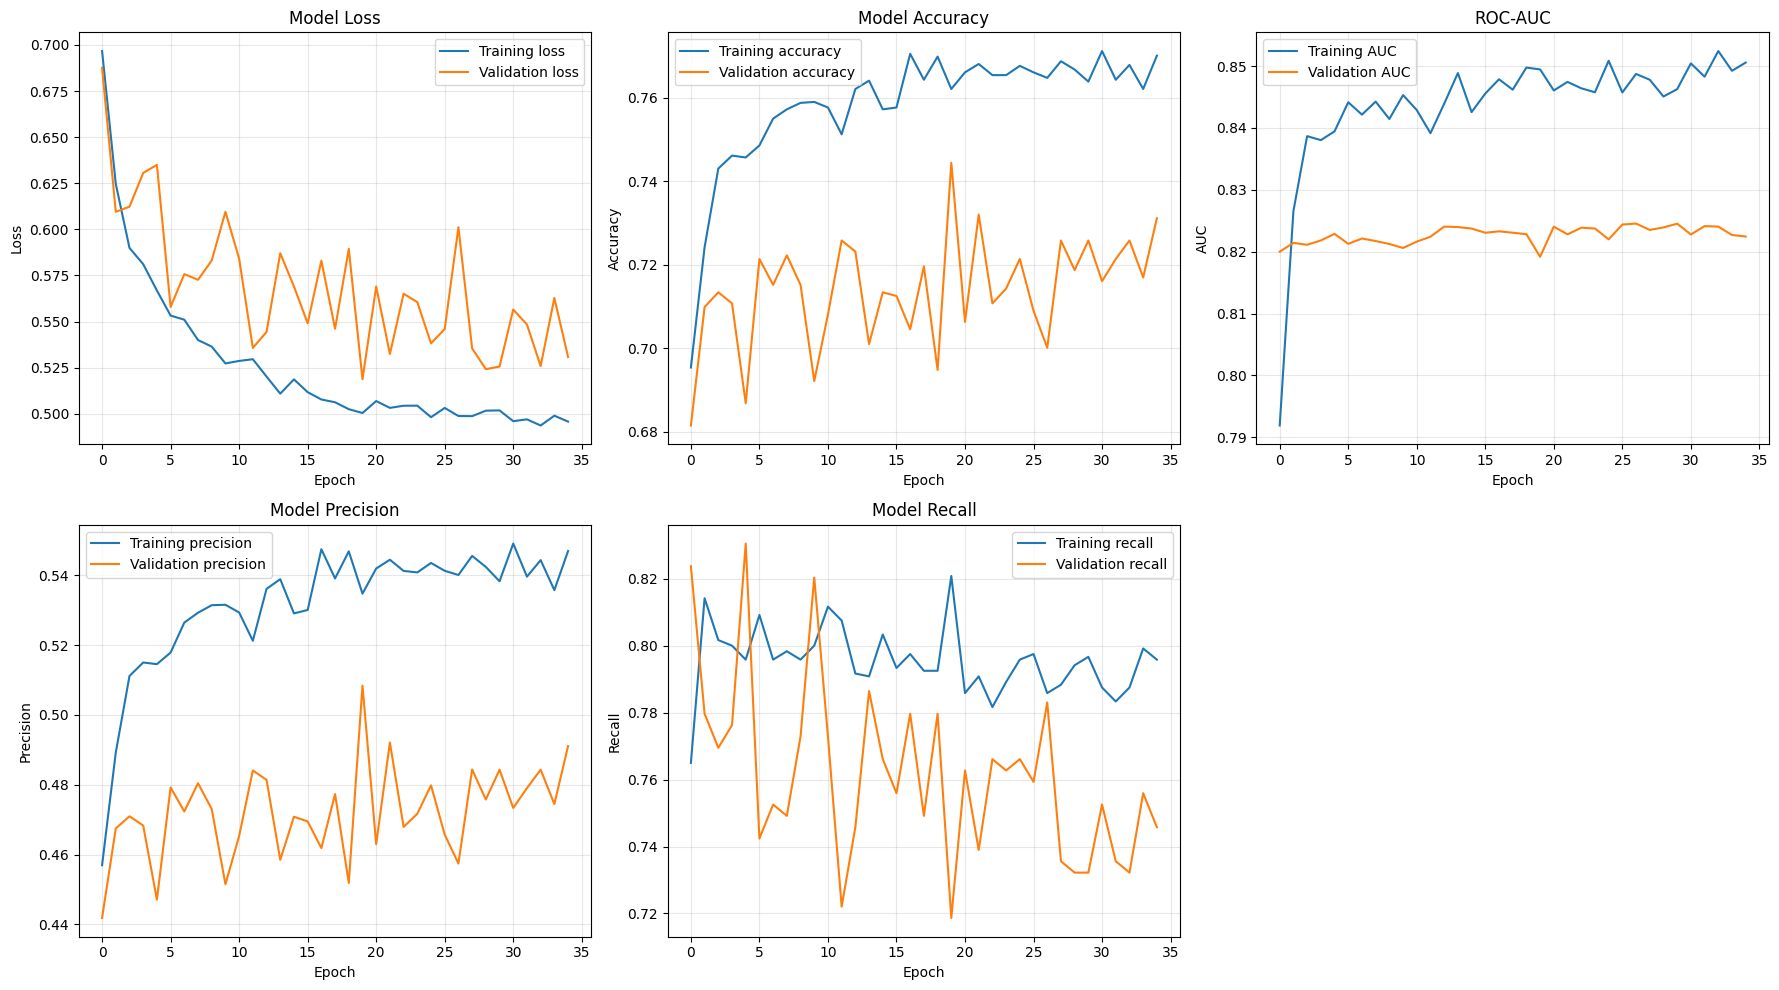

In [ ]:
visualize_history(trained_model)

In [ ]:
def evaluate_nn(model, X_test, y_test, threshold=0.5):
  y_pred_prob = model.predict(X_test)
  y_predictions = (y_pred_prob > threshold).astype(int)

  print(classification_report(y_test, y_predictions, target_names=['No churn', 'Churn']))
  print("AUC:", roc_auc_score(y_test, y_pred_prob))

  # confusion matrix
  cm = confusion_matrix(y_test, y_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()
  plt.show()

In [ ]:
def plot_tpr_fpr(y_test, y_pred_prob):
  """
  Plot ROC Curves
  """
  fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)
  # roc_auc = auc(fpr, tpr)

  precision, recall, threshold_pr = precision_recall_curve(y_test, y_pred_prob)
  # avg_precision = average_precision_score(y_test, y_pred_prob)

  fig, axes = plt.subplots(1, 2, figsize=(10,6))

  # ROC Curve
  axes[0].plot(fpr, tpr, color='blue', lw=2, label='ROC Curve')
  axes[0].set_xlabel('False Positive Rate (FPR)')
  axes[0].set_ylabel('True Positive Rate (TPR)')
  axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
  axes[0].legend(loc='lower right')
  axes[0].grid(alpha=0.5)

  # Precision recall
  axes[1].plot(recall, precision, color='green', lw=2, label='PR Curve')
  axes[1].set_xlabel('Recall')
  axes[1].set_ylabel('Precision')
  axes[1].set_title('Precision-Recall Curve')
  axes[1].legend(loc='lower left')
  axes[1].grid(alpha=0.5)

  plt.tight_layout()

  plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    No churn       0.89      0.77      0.82      1035
       Churn       0.53      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

AUC: 0.8334211682037769


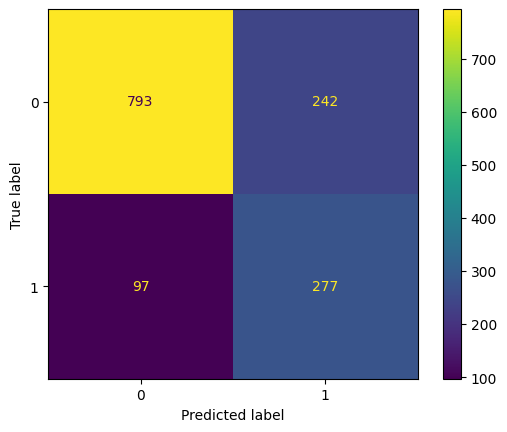

In [ ]:
evaluate_nn(neural_network, X_test_selected, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

    No churn       0.91      0.70      0.79      1035
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.74      1409

AUC: 0.8334211682037769


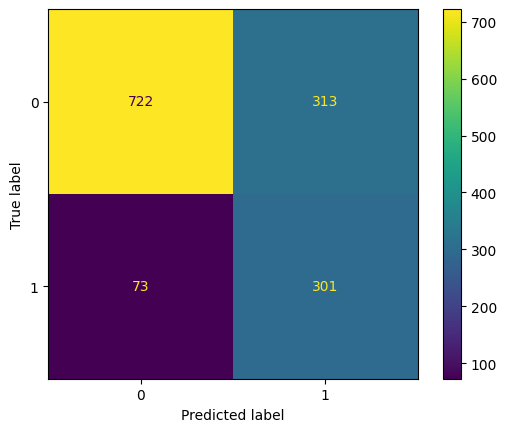

In [ ]:
evaluate_nn(neural_network, X_test_selected, y_test, threshold=0.4)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

    No churn       0.93      0.59      0.72      1035
       Churn       0.44      0.87      0.58       374

    accuracy                           0.67      1409
   macro avg       0.68      0.73      0.65      1409
weighted avg       0.80      0.67      0.69      1409

AUC: 0.8334211682037769


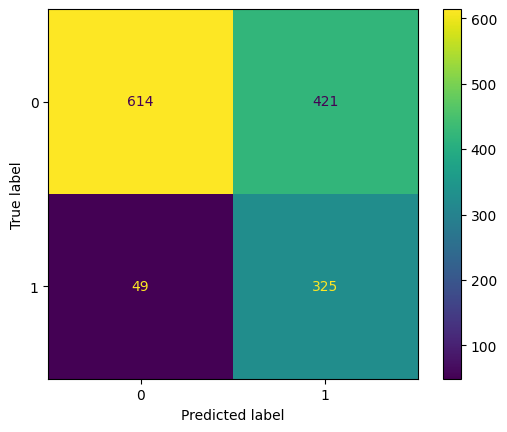

In [ ]:
evaluate_nn(neural_network, X_test_selected, y_test, threshold=0.3)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


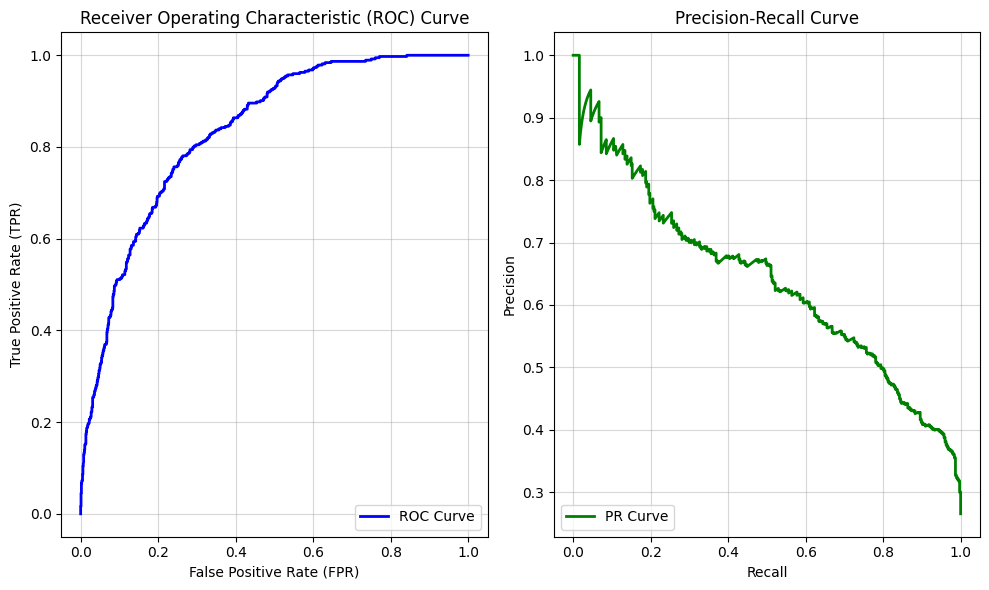

In [ ]:
plot_tpr_fpr(y_test, neural_network.predict(X_test_selected))

## **Neural Network Interpretation**

In [ ]:
# Choose background for shap
background = shap.sample(X_train_selected, 100)

In [ ]:
# Create the explainer
explainer = shap.KernelExplainer(neural_network, background)

In [ ]:
# generate shap values
shap_values = explainer.shap_values(X_test_selected[:200])  # subset for speed

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
selected_mask = selector.get_support()

In [ ]:
# Get the previously selected names
selected_feature_names = preprocessor.get_feature_names_out()[selected_mask]

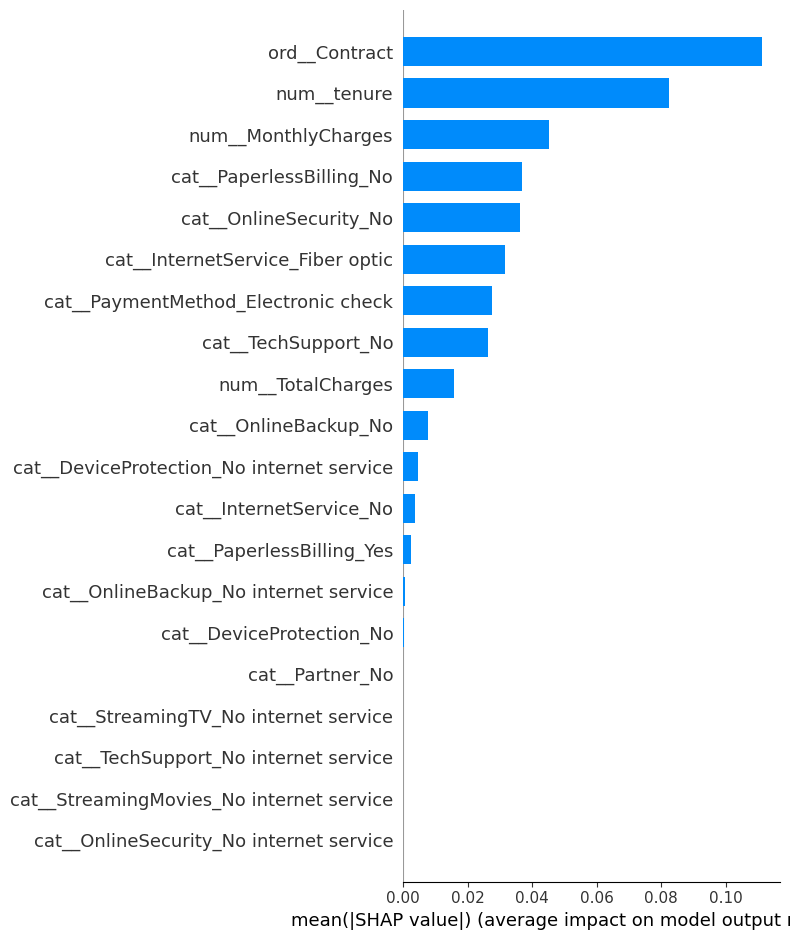

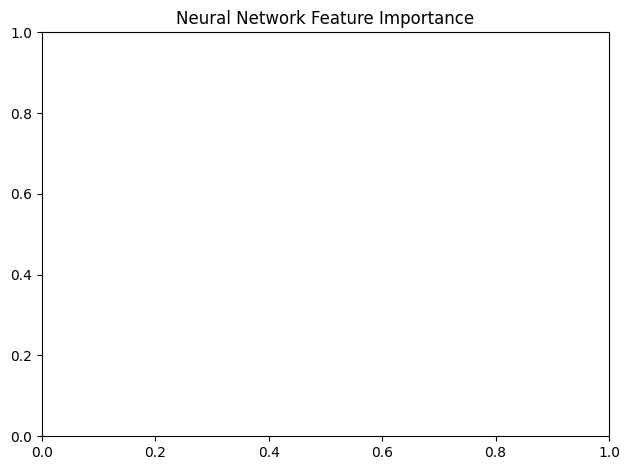

In [ ]:
 # Summary plot of feature importance
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values[:, :, 0], X_test_selected[:200],
                  feature_names=selected_feature_names,
                  plot_type='bar')
plt.clf()
plt.close() # remove the empty plot
plt.title('Neural Network Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# forceplot for predictions
shap.initjs()
shap.force_plot(explainer.expected_value[0],
                shap_values[0].flatten(),
                X_test_selected[0],
                feature_names=selected_feature_names)

# **Hyperparameter Tuning**

In [ ]:
input_dim = X_train_selected.shape[1]

def tune(parameter):
  """
  Used to tune the neural network
  """
  global input_dim
  model = keras.Sequential()
  model.add(tf.keras.layers.Input(shape=(input_dim, ))) # input_dim for number of features

  # Tune number of layers
  for i in range(parameter.Int('num_layers', 1, 3)): # try 1 to 3 hidden layers (different amounts may be underfitting/overfitting)
    model.add(tf.keras.layers.Dense(
        units=parameter.Int(f'units_{i}', min_value=32, max_value=256, step=32),

        # relu to prevent vanising gradients and suited for hidden layers
        activation='relu',

        # Prevent overfitting
        kernel_regularizer=regularizers.l2(parameter.Float('l2', 1e-5, 1e-1, sampling='log'))
    ))
    model.add(tf.keras.layers.Dropout(parameter.Float('dropout', 0.1, 0.5, step=0.1)))

    # Normalize output of previous layers
    model.add(tf.keras.layers.BatchNormalization())

  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  model.compile(

                # Tune learning rate with log values
      optimizer=tf.keras.optimizers.Adam(
          learning_rate=parameter.Float('learning_rate', 1e-4, 1e-2, sampling='log')
      ),
      loss='binary_crossentropy', # for binrary classification
      metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # better for imbalanced data than accuracy
  )
  return model

In [ ]:
# Run hyperparameter search
tuner = RandomSearch(
    tune,
    objective='val_auc',
    max_trials=10,
    executions_per_trial=2,
    directory='tuner_results'
)

In [ ]:
tuner.search(
    X_train_selected,
    y_train,
    epochs=30,
    validation_data=(X_test_selected, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)]
)

Trial 10 Complete [00h 00m 32s]
val_auc: 0.8333868980407715

Best val_auc So Far: 0.8424675464630127
Total elapsed time: 00h 08m 01s


In [ ]:
# Get the best hyperparameters
best_hyper_parameters = tuner.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
# Get the best layers
print("Best number of layers:", best_hyper_parameters.get('num_layers'))

Best number of layers: 1


In [ ]:
for i in range(best_hyper_parameters.get('num_layers')):
    print(f"Best units in layer {i}:", best_hyper_parameters.get(f'units_{i}'))
    print("Best dropout rate:", best_hyper_parameters.get('dropout'))
    print("Best L2:", best_hyper_parameters.get('l2'))
    print("Best learning rate:", best_hyper_parameters.get('learning_rate'))

Best units in layer 0: 128
Best dropout rate: 0.4
Best L2: 0.0014437698841694771
Best learning rate: 0.0007225512827033819


In [ ]:
best_model = tuner.hypermodel.build(best_hyper_parameters)

In [ ]:
history = best_model.fit(
    X_train_selected,
    y_train,
    epochs=100,  # more epochs now
    batch_size=32,
    validation_data=(X_test_selected, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6324 - auc: 0.6629 - loss: 0.7270 - val_accuracy: 0.7736 - val_auc: 0.8125 - val_loss: 0.5104
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7779 - auc: 0.8033 - loss: 0.5190 - val_accuracy: 0.7779 - val_auc: 0.8242 - val_loss: 0.4851
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7781 - auc: 0.8050 - loss: 0.5060 - val_accuracy: 0.7935 - val_auc: 0.8346 - val_loss: 0.4658
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7750 - auc: 0.8130 - loss: 0.5017 - val_accuracy: 0.7942 - val_auc: 0.8354 - val_loss: 0.4625
Epoch 5/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7876 - auc: 0.8252 - loss: 0.4762 - val_accuracy: 0.7892 - val_auc: 0.8328 - val_loss: 0.4648
Epoch 6/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7762 - auc: 0.8162 - loss: 0.4861 - val_accuracy: 0.7984 - val_auc: 0.8356 - val_loss: 0.4588
Epoch 7/100
177/177 ━━━━━━━━━━━━━━

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC: 0.8382159187785787


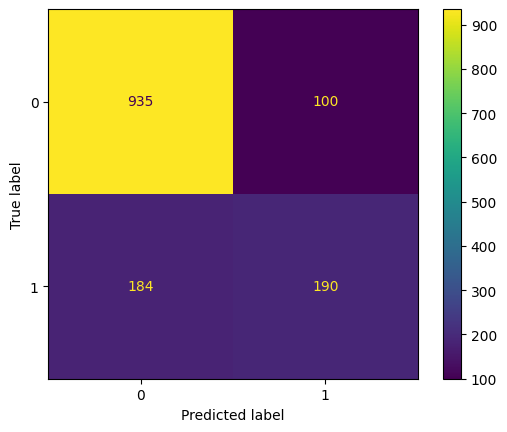

In [ ]:
evaluate_nn(best_model, X_test_selected, y_test)  # threshold of 0.5

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    No churn       0.86      0.85      0.86      1035
       Churn       0.60      0.63      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409

AUC: 0.8382159187785787


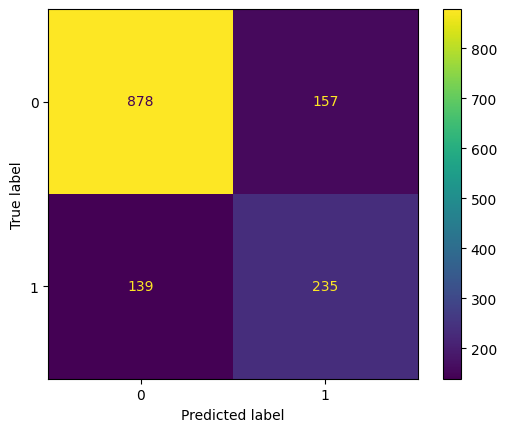

In [ ]:
evaluate_nn(best_model, X_test_selected, y_test, threshold=0.4)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

    No churn       0.90      0.78      0.83      1035
       Churn       0.55      0.76      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

AUC: 0.8382159187785787


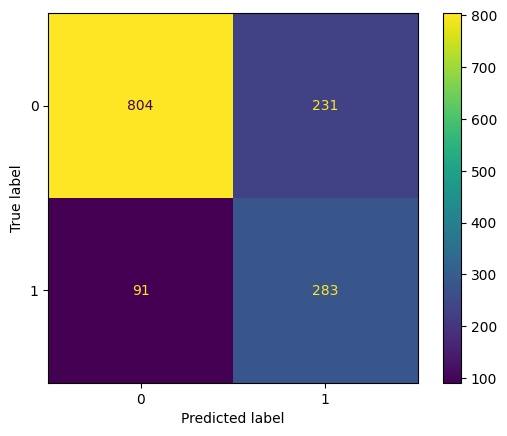

In [ ]:
evaluate_nn(best_model, X_test_selected, y_test, threshold=0.3)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


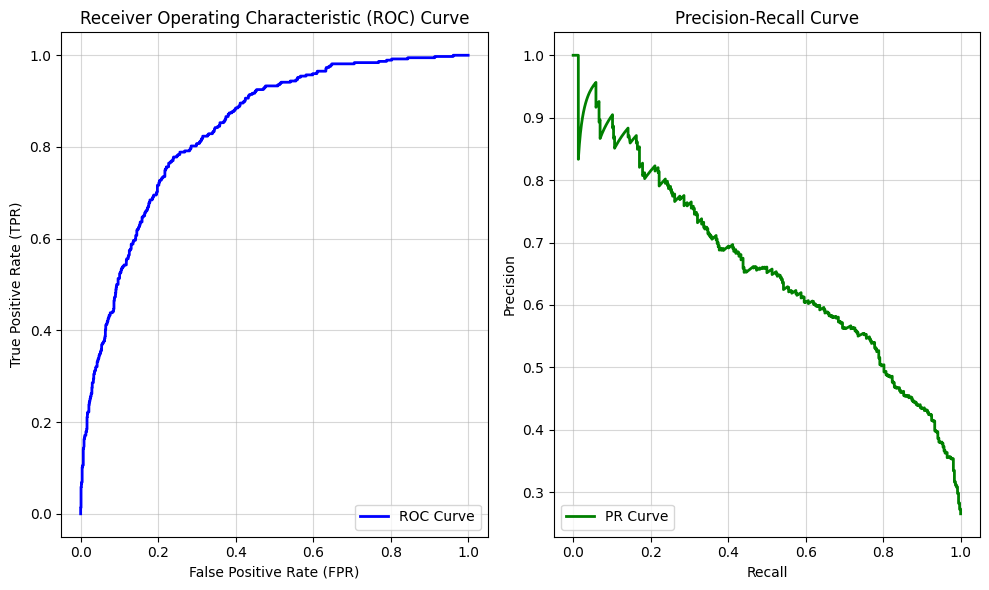

In [ ]:
plot_tpr_fpr(y_test, best_model.predict(X_test_selected))

In [ ]:
# save model
best_model.save('neural_model.h5')
